In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [6]:
df = pd.read_csv('data/titanic_toy.csv')
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [7]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [8]:
df.isnull().sum()

Age         177
Fare         45
Family        0
Survived      0
dtype: int64

## 1.Mean and Median technique value impution

### Using Pandas 

In [9]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [11]:
X_train.head()

,Age,Fare,Family
30,40.0,27.7208,0
10,4.0,16.7000,2
873,47.0,9.0000,0
182,9.0,31.3875,6
876,20.0,9.8458,0


In [13]:
X_train.isnull().mean()

Age       0.207865
Fare      0.050562
Family    0.000000
dtype: float64

In [17]:
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

In [18]:
X_train['Age_mean'] = X_train['Age'].fillna(mean_age)
X_train['Age_median'] = X_train['Age'].fillna(median_age)

In [19]:
X_train

,Age,Fare,Family,Age_mean,Age_median
30,40.0,27.7208,0,40.000000,40.00
10,4.0,16.7000,2,4.000000,4.00
873,47.0,9.0000,0,47.000000,47.00
182,9.0,31.3875,6,9.000000,9.00
876,20.0,9.8458,0,20.000000,20.00
...,...,...,...,...,...
534,30.0,8.6625,0,30.000000,30.00
584,NaN,8.7125,0,29.785904,28.75
493,71.0,49.5042,0,71.000000,71.00
527,NaN,221.7792,0,29.785904,28.75


In [20]:
mean_fare = X_train['Fare'].mean()
median_fare = X_train['Fare'].median()

In [21]:
X_train['Fare_mean'] = X_train['Fare'].fillna(mean_fare)
X_train['Fare_median'] = X_train['Fare'].fillna(median_fare)

In [24]:
X_train.sample(10)

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
82,NaN,NaN,0,29.785904,28.75,32.617597,14.4583
744,31.0,7.9250,0,31.000000,31.00,7.925000,7.9250
665,32.0,73.5000,2,32.000000,32.00,73.500000,73.5000
27,19.0,263.0000,5,19.000000,19.00,263.000000,263.0000
287,22.0,7.8958,0,22.000000,22.00,7.895800,7.8958
779,43.0,211.3375,1,43.000000,43.00,211.337500,211.3375
281,28.0,NaN,0,28.000000,28.00,32.617597,14.4583
94,59.0,7.2500,0,59.000000,59.00,7.250000,7.2500
332,38.0,153.4625,1,38.000000,38.00,153.462500,153.4625
177,50.0,28.7125,0,50.000000,50.00,28.712500,28.7125


### Check the variance of data

In [27]:
print("Original Age variable variance",X_train['Age'].var())
print("Age variance After median imputaion ",X_train['Age_median'].var())
print("Age variance After mean imputaion",X_train['Age_mean'].var())

Original Age variable variance 204.3495133904614
 Age variance After median imputaion  161.9895663346054
Age variance After mean imputaion 161.81262452718673


In [29]:
print("Original Fare variable variance",X_train['Fare'].var())
print("Fare variance After median imputaion ",X_train['Fare_median'].var())
print("Fare variance After mean imputaion",X_train['Fare_mean'].var())

Original Fare variable variance 2448.197913706318
Fare variance After median imputaion  2340.0910219753637
Fare variance After mean imputaion 2324.2385256705547


### Check the distribution of data

<Axes: ylabel='Density'>

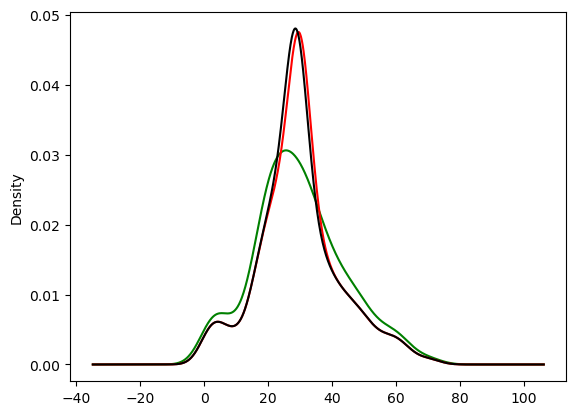

In [34]:
X_train['Age'].plot(kind='kde', color='green')
X_train['Age_mean'].plot(kind='kde',color='red')
X_train['Age_median'].plot(kind='kde',color='black')

<Axes: ylabel='Density'>

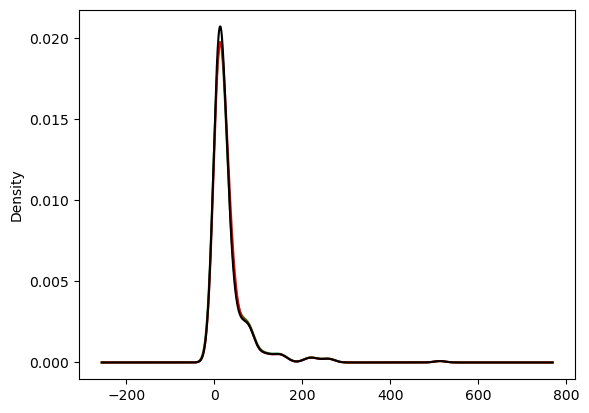

In [35]:
X_train['Fare'].plot(kind='kde', color='green')
X_train['Fare_mean'].plot(kind='kde',color='red')
X_train['Fare_median'].plot(kind='kde',color='black')

### Covariance of dat

In [36]:
X_train.cov()

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,66.665205,64.858859
Fare,70.719262,2448.197914,17.258917,55.603719,57.957599,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-5.146106,-5.112563,16.385048,16.476305
Age_mean,204.349513,55.603719,-5.146106,161.812625,161.812625,52.788341,51.358000
Age_median,204.349513,57.957599,-5.112563,161.812625,161.989566,55.023037,53.553455
Fare_mean,66.665205,2448.197914,16.385048,52.788341,55.023037,2324.238526,2324.238526
Fare_median,64.858859,2448.197914,16.476305,51.358000,53.553455,2324.238526,2340.091022


### Covariation of data (-1 to +1)

In [37]:
X_train.corr()

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.090156,0.087356
Fare,0.092644,1.000000,0.208268,0.088069,0.091757,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.244610,-0.242883,0.205499,0.205942
Age_mean,1.000000,0.088069,-0.244610,1.000000,0.999454,0.086078,0.083461
Age_median,1.000000,0.091757,-0.242883,0.999454,1.000000,0.089673,0.086982
Fare_mean,0.090156,1.000000,0.205499,0.086078,0.089673,1.000000,0.996607
Fare_median,0.087356,1.000000,0.205942,0.083461,0.086982,0.996607,1.000000


### Increase outliers

<Axes: >

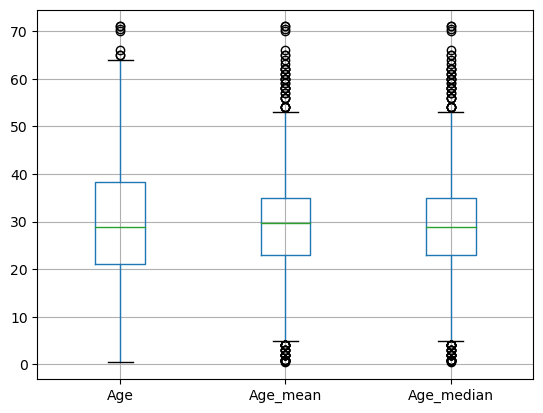

In [40]:
X_train[['Age','Age_mean','Age_median']].boxplot()
#Outliers are increase

<Axes: >

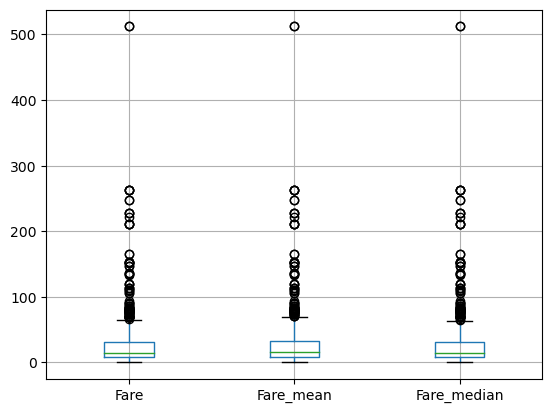

In [41]:
X_train[['Fare','Fare_mean','Fare_median']].boxplot()

#### Conclusion:This stage we use the mean ,median tech. on only fare column because there is no change in distribution, covariation,covariance and outliers and it shows the red flag on age columns

### Using Sklearn

In [43]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [47]:
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

In [48]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

In [49]:
trf.fit(X_train)

ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(strategy='median'),
                                 ['Age']),
                                ('imputer2', SimpleImputer(), ['Fare'])])

In [51]:
trf.named_transformers_['imputer1'].statistics_

array([28.75])

In [52]:
trf.named_transformers_['imputer2'].statistics_

array([32.61759689])

In [53]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [54]:
X_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 28.75  , 221.7792,   0.    ],
       [ 28.75  ,  25.925 ,   0.    ]])

## 2.Arbitray value imputation


### Using Pandas 

In [55]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [56]:
X_train['Age_99'] = X_train['Age'].fillna(99)
X_train['Age_min'] = X_train['Age'].fillna(-1)

In [57]:
X_train['Fare_999'] = X_train['Fare'].fillna(999)
X_train['Fare_min'] = X_train['Fare'].fillna(-1)

In [58]:
X_train

,Age,Fare,Family,Age_99,Age_min,Fare_999,Fare_min
30,40.0,27.7208,0,40.0,40.0,27.7208,27.7208
10,4.0,16.7000,2,4.0,4.0,16.7000,16.7000
873,47.0,9.0000,0,47.0,47.0,9.0000,9.0000
182,9.0,31.3875,6,9.0,9.0,31.3875,31.3875
876,20.0,9.8458,0,20.0,20.0,9.8458,9.8458
...,...,...,...,...,...,...,...
534,30.0,8.6625,0,30.0,30.0,8.6625,8.6625
584,NaN,8.7125,0,99.0,-1.0,8.7125,8.7125
493,71.0,49.5042,0,71.0,71.0,49.5042,49.5042
527,NaN,221.7792,0,99.0,-1.0,221.7792,221.7792


In [59]:
print("Original Age variable variance",X_train['Age'].var())
print("Age variance After 999 imputaion ",X_train['Age_99'].var())
print("Age variance After -1 imputaion",X_train['Age_min'].var())
print("Original Fare variable variance",X_train['Fare'].var())
print("Fare variance After 999 imputaion ",X_train['Fare_999'].var())
print("Fare variance After -1 imputaion",X_train['Fare_min'].var())

Original Age variable variance 204.3495133904614
Age variance After 999 imputaion  951.7275570187172
Age variance After -1 imputaion 318.0896202624484
Original Fare variable variance 2448.197913706318
Fare variance After 999 imputaion  47219.20265217623
Fare variance After -1 imputaion 2378.5676784883503


<Axes: ylabel='Density'>

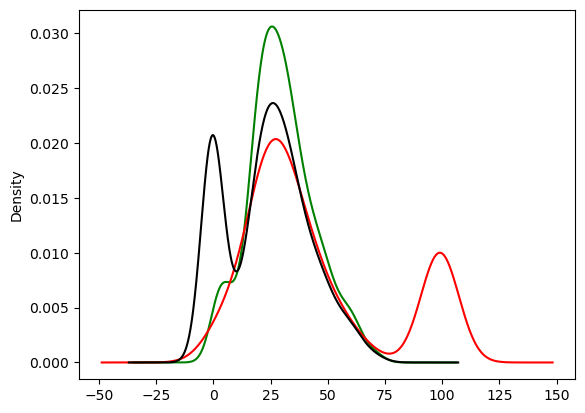

In [60]:
X_train['Age'].plot(kind='kde', color='green')
X_train['Age_99'].plot(kind='kde',color='red')
X_train['Age_min'].plot(kind='kde',color='black')

<Axes: ylabel='Density'>

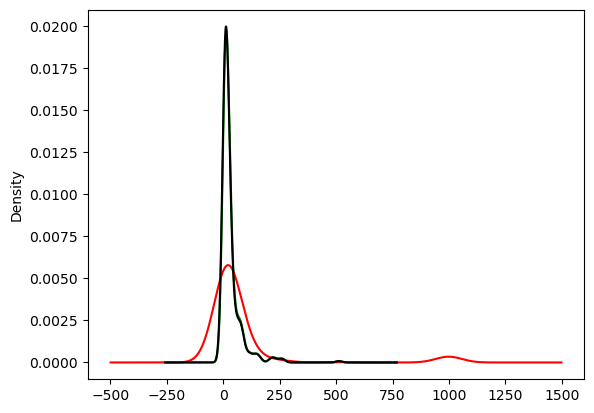

In [61]:
X_train['Fare'].plot(kind='kde', color='green')
X_train['Fare_999'].plot(kind='kde',color='red')
X_train['Fare_min'].plot(kind='kde',color='black')

In [62]:
X_train.cov()

,Age,Fare,Family,Age_99,Age_min,Fare_999,Fare_min
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,162.793430,63.321188
Fare,70.719262,2448.197914,17.258917,-101.671097,125.558364,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-7.387287,-4.149246,11.528625,16.553989
Age_99,204.349513,-101.671097,-7.387287,951.727557,-189.535540,-159.931663,-94.317400
Age_min,204.349513,125.558364,-4.149246,-189.535540,318.089620,257.379887,114.394141
Fare_999,162.793430,2448.197914,11.528625,-159.931663,257.379887,47219.202652,762.474982
Fare_min,63.321188,2448.197914,16.553989,-94.317400,114.394141,762.474982,2378.567678


In [63]:
X_train.corr()

,Age,Fare,Family,Age_99,Age_min,Fare_999,Fare_min
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.051179,0.084585
Fare,0.092644,1.000000,0.208268,-0.066273,0.142022,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.144787,-0.140668,0.032079,0.205233
Age_99,1.000000,-0.066273,-0.144787,1.000000,-0.344476,-0.023857,-0.062687
Age_min,1.000000,0.142022,-0.140668,-0.344476,1.000000,0.066411,0.131514
Fare_999,0.051179,1.000000,0.032079,-0.023857,0.066411,1.000000,0.071946
Fare_min,0.084585,1.000000,0.205233,-0.062687,0.131514,0.071946,1.000000


### Using Sklearn

In [64]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [65]:
imputer1 = SimpleImputer(strategy='constant',fill_value=99)
imputer2 = SimpleImputer(strategy='constant',fill_value=999)

In [66]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

In [67]:
trf.fit(X_train)

ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1',
                                 SimpleImputer(fill_value=99,
                                               strategy='constant'),
                                 ['Age']),
                                ('imputer2',
                                 SimpleImputer(fill_value=999,
                                               strategy='constant'),
                                 ['Fare'])])

In [69]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [70]:
X_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 99.    , 221.7792,   0.    ],
       [ 99.    ,  25.925 ,   0.    ]])